# B4222 Project Source Code - Twitters Feature Engineering

In [3]:
# connect google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Libraries

In [5]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.1 MB/s eta 0:00:00


In [7]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import re
import emoji
import ast

# Load Dataset

In [42]:
# load dataset
df_tweets = pd.read_parquet("/content/drive/MyDrive/BT4222/Project/data/twibot-22/df_user_tweets_final.parquet")
df = pd.read_parquet("/content/drive/MyDrive/BT4222/Project/data/twibot-22/df_users_final.parquet")

# copy dataset
df_tweets = df_tweets.copy()
df = df.copy()

# Data Inspection

In [8]:
# display data
df_tweets.head(20)

,id,tweets
0,u1236224386639765505,[]
1,u838298700896153601,[]
2,u14250598,[]
3,u217722834,[]
4,u174646559,[]
5,u963220649811611648,[{'attachments': '{'media_keys': ['16_14125075...
6,u19901349,[]
7,u1443045195323518982,"[{'attachments': None, 'author_id': 'u14430451..."
8,u1188062140524974080,[]
9,u576188032,"[{'attachments': None, 'author_id': 'u57618803..."


In [9]:
# display information of data
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20000 non-null  object
 1   tweets  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [10]:
# display data
df.head()

,id,label,split,participation_degree,created_at,description,location,name,pinned_tweet_id,profile_image_url,...,entities.description.urls,public_metrics.followers_count,public_metrics.following_count,public_metrics.tweet_count,public_metrics.listed_count,entities,entities.description.mentions,entities.description.hashtags,entities.description.cashtags,withheld.country_codes
0,u1217628182611927040,human,test,1565,2020-01-16 02:02:55+00:00,Theoretical Computer Scientist. See also https...,"Cambridge, MA",Boaz Barak,NaN,https://pbs.twimg.com/profile_images/125226236...,...,"[{'display_url': 'windowsontheory.org', 'end':...",7316,215,3098,69,NaN,None,None,None,None
1,u1679822588,bot,train,1097,2013-08-18 04:21:48+00:00,,🇬🇧,Grian,1.143808e+18,https://pbs.twimg.com/profile_images/100773461...,...,None,238254,293,1400,448,NaN,None,None,None,None
2,u1519144464,human,train,1066,2013-06-15 11:34:55+00:00,The hottest brownboy in the game. ...,"Umhlanga, South Africa",Nikhil Sewdass,NaN,https://pbs.twimg.com/profile_images/146310691...,...,None,161,278,788,0,NaN,None,None,None,None
3,u15211869,human,train,1914,2008-06-23 20:59:59+00:00,"Director, Knowledge Ecology International, an ...","ÜT: 38.911326,-77.04508",James Love,1.335259e+18,https://pbs.twimg.com/profile_images/126138453...,...,None,10299,2166,57397,383,NaN,None,None,None,None
4,u1341789703633178624,bot,test,158,2020-12-23 16:56:30+00:00,,None,mo,NaN,https://abs.twimg.com/sticky/default_profile_i...,...,None,0,136,6,0,NaN,None,None,None,None


In [11]:
# display information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20000 non-null  object 
 1   label                           20000 non-null  object 
 2   split                           20000 non-null  object 
 3   participation_degree            20000 non-null  int64  
 4   created_at                      20000 non-null  object 
 5   description                     20000 non-null  object 
 6   location                        14642 non-null  object 
 7   name                            20000 non-null  object 
 8   pinned_tweet_id                 9680 non-null   float64
 9   profile_image_url               20000 non-null  object 
 10  protected                       20000 non-null  bool   
 11  url                             20000 non-null  object 
 12  username                        

## Tweets Inspection

In [12]:
# count number of users with no tweets and number of users with tweets
no_tweets_count = df_tweets['tweets'].apply(lambda x: len(x) == 0).sum()
tweets_count = df_tweets['tweets'].apply(lambda x: len(x) > 0).sum()

print("Users with no tweets: ", no_tweets_count)
print("Users with tweets: ", tweets_count)

Users with no tweets:  15109
Users with tweets:  4891


In [13]:
# descriptive statistics of tweets (for all users)
df_tweets_copy = df_tweets.copy()
df_tweets_copy['num_tweets'] = df_tweets_copy['tweets'].apply(lambda x: len(x))
df_tweets_copy['num_tweets'].describe()

,num_tweets
count,20000.000000
mean,7.605450
std,49.798829
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1526.000000


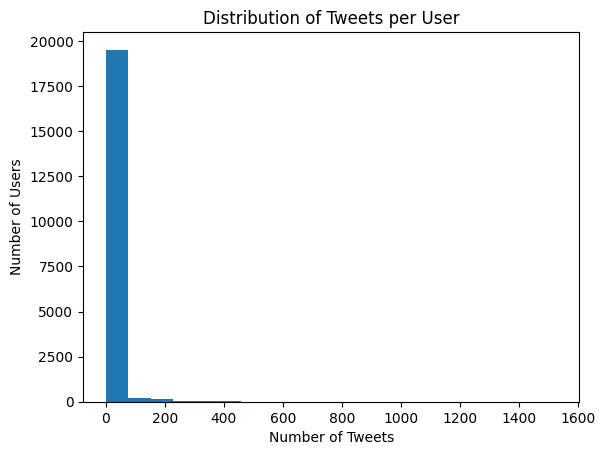

In [14]:
# histogram of tweets per user (for all users)
plt.figure()
plt.hist(df_tweets_copy['num_tweets'], bins=20)

plt.xlabel('Number of Tweets')
plt.ylabel('Number of Users')
plt.title('Distribution of Tweets per User')

plt.show()

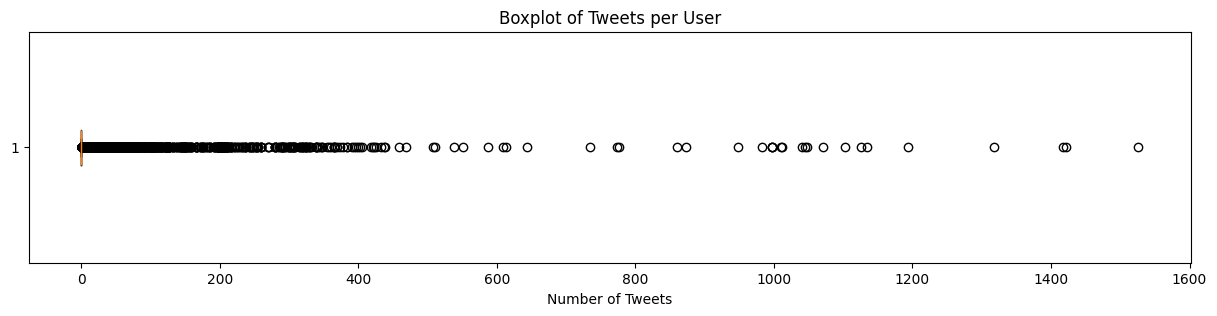

In [15]:
# boxplot of tweets per user (for all users)
plt.figure(figsize=(15, 3))
plt.boxplot(df_tweets_copy['num_tweets'], vert=False)

plt.xlabel('Number of Tweets')
plt.title('Boxplot of Tweets per User')

plt.show()

In [16]:
# descriptive statistics of tweets (for users with tweets)
df_tweets_users_with_tweets = df_tweets[df_tweets['tweets'].apply(lambda x: len(x)) > 0].copy()
df_tweets_users_with_tweets ['num_tweets'] = df_tweets_users_with_tweets ['tweets'].apply(lambda x: len(x))
df_tweets_users_with_tweets ['num_tweets'].describe()

,num_tweets
count,4891.000000
mean,31.099775
std,97.012943
min,1.000000
25%,1.000000
50%,5.000000
75%,15.000000
max,1526.000000


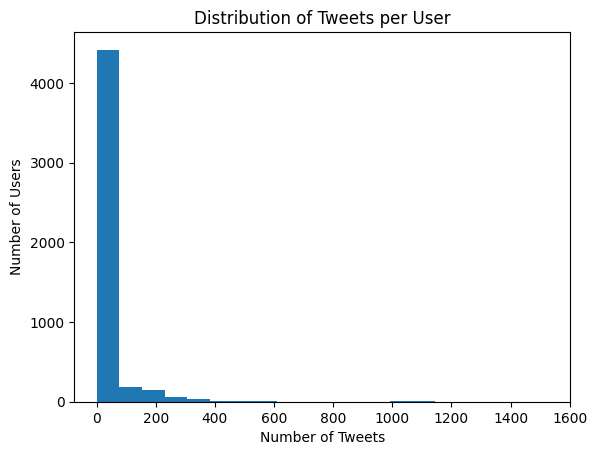

In [17]:
# histogram of tweets per user (for users with tweets)
plt.figure()
plt.hist(df_tweets_users_with_tweets ['num_tweets'], bins=20)

plt.xlabel('Number of Tweets')
plt.ylabel('Number of Users')
plt.title('Distribution of Tweets per User')

plt.show()

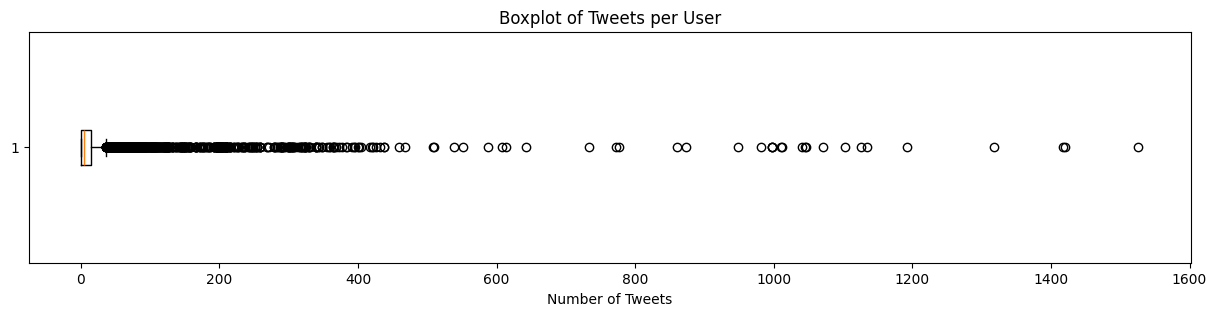

In [18]:
# boxplot of tweets per user (for users with tweets)
plt.figure(figsize=(15, 3))
plt.boxplot(df_tweets_users_with_tweets ['num_tweets'], vert=False)

plt.xlabel('Number of Tweets')
plt.title('Boxplot of Tweets per User')

plt.show()

# Feature Engineering

## User Activity Features

In [43]:
# number tweets
df_tweets["num_tweets"] = df_tweets["tweets"].apply(lambda x: len(x))

In [44]:
# tweet frequency -> average number of tweets per day relative to age
# lookup dictionary: user_id -> created_at
created_at_map = df.set_index('id')['created_at'].to_dict()

def compute_tweet_frequency(row):
  tweet_list = row['tweets']
  user_id = row['id']

  # number of tweets
  num_tweets = row['num_tweets']

  if num_tweets == 0:
    return 0

  # account creation date
  created_at_str = created_at_map.get(user_id)

  if created_at_str is None:
    return 0

  # parse datetime
  created_at = datetime.fromisoformat(created_at_str.replace('Z', '+00:00'))

  # current reference time
  now = datetime.now(created_at.tzinfo)

  account_age_days = (now - created_at).days

  # avoid division by 0
  if account_age_days <= 0:
    return 0

  return num_tweets / account_age_days

df_tweets['tweets_frequency'] = df_tweets.apply(compute_tweet_frequency, axis=1)

In [45]:
# posting regularity -> variance of time gaps between consecutive tweets
def compute_posting_regularity(tweet_list):
  timestamps = []

  # extract timestamps
  for t in tweet_list:
    if 'created_at' in t:
      timestamps.append(
        datetime.fromisoformat(t['created_at'].replace('Z', '+00:00'))
      )

  # edge cases
  if len(timestamps) <= 2:
    return 0  # not enough data to compute meaningful variance

  timestamps.sort()

  # compute time differences in days
  diffs = [
    (timestamps[i] - timestamps[i-1]).total_seconds() / (60*60*24)
    for i in range(1, len(timestamps))
  ]

  return np.var(diffs)

df_tweets['posting_regularity'] = df_tweets['tweets'].apply(compute_posting_regularity)

## Content Features

In [62]:
# text length
def compute_text_length(tweet_list):
  lengths = []
  word_counts = []
  word_lengths = []

  for tweet in tweet_list:
    text = tweet.get('text')

    # skip if text is None or empty
    if text is None:
      continue

    # character length
    char_len = len(text)
    lengths.append(char_len)

    # words
    words = re.findall(r'\w+', text)
    word_counts.append(len(words))

    # avg word length in this tweet
    if len(words) > 0:
      word_lengths.append(sum(len(w) for w in words) / len(words))

  # aggregate across tweets in the row
  if len(lengths) == 0:
    return pd.Series([0, 0, 0])

  avg_length = sum(lengths) / len(lengths)
  avg_words = sum(word_counts) / len(word_counts)
  avg_word_length = sum(word_lengths) / len(word_lengths)

  return pd.Series([avg_length, avg_words, avg_word_length])

df_tweets[['avg_length_per_tweet',
           'avg_words_per_tweet',
           'avg_word_length_per_tweet']] = df_tweets['tweets'].apply(compute_text_length)

# make overuse_hashtags binary
df_tweets['overuse_hashtags'] = df_tweets['overuse_hashtags'].astype(int)

In [47]:
# text style
def compute_text_style(tweet_list):
  uppercase_pct = []
  digit_pct = []
  special_char_pct = []
  emoji_count = []

  for tweet in tweet_list:
    text = tweet.get('text')

    # skip if text is None or empty
    if text is None:
      continue

    total_chars = len(text)

    uppercase_count = sum(1 for c in text if c.isupper())
    uppercase_pct.append(uppercase_count / total_chars)

    digit_count = sum(1 for c in text if c.isdigit())
    digit_pct.append(digit_count / total_chars)

    special_chars = 0
    for c in text:
        if not c.isalnum() and c not in [' ', '#', '@']:
            special_chars += 1
    special_char_pct.append(special_chars / total_chars)

    emoji_count.append(len(emoji.emoji_list(text)))

  if len(tweet_list) == 0:
      return pd.Series([0, 0, 0, 0])

  return pd.Series([
      sum(uppercase_pct) / len(uppercase_pct),
      sum(digit_pct) / len(digit_pct),
      sum(special_char_pct) / len(special_char_pct),
      sum(emoji_count) / len(emoji_count)
  ])

df_tweets[['avg_uppercase_pct',
           'avg_digit_pct',
           'avg_special_char_pct',
           'avg_emoji']] = df_tweets['tweets'].apply(compute_text_style)

In [48]:
# hashtags
def compute_hashtag(tweet_list):
  hashtags_per_tweet = []
  unique_hashtags_per_tweet = []
  has_hashtag_flags = []

  for tweet in tweet_list:
    entities = tweet.get('entities')

    if not entities:
      continue

    if isinstance(entities, str):
      try:
        entities_dict = ast.literal_eval(entities)
      except:
        continue
    else:
      entities_dict = entities

    hashtags = entities_dict.get('hashtags', [])

    hashtag_tags = []
    for h in hashtags:
      if isinstance(h, dict) and 'tag' in h:
        hashtag_tags.append(h['tag'])

    hashtags_per_tweet.append(len(hashtag_tags))
    unique_hashtags_per_tweet.append(len(set(hashtag_tags)))
    has_hashtag_flags.append(1 if len(hashtag_tags) > 0 else 0)

  if len(hashtags_per_tweet) == 0:
    return pd.Series([0, 0, 0])

  avg_hashtags = sum(hashtags_per_tweet) / len(hashtags_per_tweet)
  avg_unique_hashtags = sum(unique_hashtags_per_tweet) / len(unique_hashtags_per_tweet)
  pct_tweets_with_hashtags = sum(has_hashtag_flags) / len(has_hashtag_flags)

  overuse_hashtags = 1 if avg_unique_hashtags < avg_hashtags else 0

  return pd.Series([avg_hashtags, overuse_hashtags, pct_tweets_with_hashtags])

df_tweets[['avg_hashtags_per_tweet',
           'overuse_hashtags',
           'pct_tweets_with_hashtags']] = df_tweets['tweets'].apply(compute_hashtag)

In [49]:
# mentions
def compute_mention(tweet_list):
  mentions_per_tweet = []
  has_mentions_flags = []

  for tweet in tweet_list:
    entities = tweet.get('entities')

    if not entities:
      continue

    if isinstance(entities, str):
      try:
        entities_dict = ast.literal_eval(entities)
      except:
        continue
    else:
      entities_dict = entities

    mentions = entities_dict.get('mentions') or entities_dict.get('user_mentions') or []

    mentions_per_tweet.append(len(mentions))
    has_mentions_flags.append(1 if len(mentions) > 0 else 0)

  if len(mentions_per_tweet) == 0:
    return pd.Series([0, 0])

  avg_mentions = sum(mentions_per_tweet) / len(mentions_per_tweet)
  pct_tweets_with_mentions = sum(has_mentions_flags) / len(has_mentions_flags)

  return pd.Series([avg_mentions, pct_tweets_with_mentions])

df_tweets[['avg_mentions_per_tweet',
           'pct_tweets_with_mentions']] = df_tweets['tweets'].apply(compute_mention)

In [50]:
# urls
def compute_url(tweet_list):
  urls_per_tweet = []
  has_urls_flags = []

  for tweet in tweet_list:
    entities = tweet.get('entities')

    if not entities:
      continue

    if isinstance(entities, str):
      try:
        entities_dict = ast.literal_eval(entities)
      except:
        continue
    else:
      entities_dict = entities

    urls = entities_dict.get('urls', [])

    urls_per_tweet.append(len(urls))
    has_urls_flags.append(1 if len(urls) > 0 else 0)

  if len(urls_per_tweet) == 0:
    return pd.Series([0, 0])

  avg_urls = sum(urls_per_tweet) / len(urls_per_tweet)
  pct_tweets_with_urls = sum(has_urls_flags) / len(has_urls_flags)

  return pd.Series([avg_urls, pct_tweets_with_urls])

df_tweets[['avg_urls_per_tweet',
           'pct_tweets_with_urls']] = df_tweets['tweets'].apply(compute_url)

In [51]:
# media/attachment
def compute_attachment(tweet_list):
  attachments_per_tweet = []
  has_attachments_flags = []

  for tweet in tweet_list:
    attachments = tweet.get('attachments', [])

    if not attachments:
      continue

    attachments_per_tweet.append(len(attachments))
    has_attachments_flags.append(1 if len(attachments) > 0 else 0)

  if len(attachments_per_tweet) == 0:
    return pd.Series([0, 0])

  avg_attachments = sum(attachments_per_tweet) / len(attachments_per_tweet)
  pct_tweets_with_attachments = sum(has_attachments_flags) / len(has_attachments_flags)

  return pd.Series([avg_attachments, pct_tweets_with_attachments])

df_tweets[['avg_attachments_per_tweet',
           'pct_tweets_with_attachments']] = df_tweets['tweets'].apply(compute_attachment)

In [52]:
# sensitivity
def compute_sensitivity(tweet_list):
  sensitivity_per_tweet = []

  for tweet in tweet_list:
    sensitivity = tweet.get('possibly_sensitive', False)
    sensitivity_per_tweet.append(1 if sensitivity else 0)

  if len(sensitivity_per_tweet) == 0:
    return 0
  else:
    return sum(sensitivity_per_tweet) / len(sensitivity_per_tweet)

df_tweets["avg_sensitive"] = df_tweets['tweets'].apply(compute_sensitivity)

## Interaction Features

In [53]:
# type of tweets
def compute_tweet_types(tweet_list):
  retweets = 0
  quotes = 0
  replies = 0
  originals = 0

  for tweet in tweet_list:
    ref = tweet.get("referenced_tweets")
    ref_type = None

    # parse referenced_tweets if needed
    if ref is not None:
      if isinstance(ref, str):
        try:
          ref = ast.literal_eval(ref)
        except:
          ref = None

      if isinstance(ref, list) and len(ref) > 0:
        ref_type = ref[0].get("type")

    is_reply = (
        tweet.get("in_reply_to_user_id") is not None
        or ref_type == "replied_to"
    )

    # classify
    if is_reply:
      replies += 1
    elif ref_type == "retweeted":
      retweets += 1
    elif ref_type == "quoted":
      quotes += 1
    else:
      originals += 1

  num_tweets = len(tweet_list)

  if num_tweets == 0:
    return pd.Series([0, 0, 0, 0])
  else:
    return pd.Series([
        retweets / num_tweets,
        quotes / num_tweets,
        replies / num_tweets,
        originals / num_tweets
    ])

df_tweets[["avg_retweets", "avg_quotes", "avg_replies", "avg_originals"]] = (
  df_tweets["tweets"].apply(lambda x: pd.Series(compute_tweet_types(x)))
)

## Engagement Features

In [54]:
def compute_engagement(tweet_list):
  retweets_per_tweet = []
  replies_per_tweet = []
  likes_per_tweet = []
  quotes_per_tweet = []
  engagement_rate_per_tweet = []

  for tweet in tweet_list:
    metrics = tweet.get('public_metrics')

    if not metrics:
      continue

    if isinstance(metrics, str):
      try:
        metrics_dict = ast.literal_eval(metrics)
      except:
        continue
    else:
      metrics_dict = metrics

    retweets_per_tweet.append(metrics_dict.get('retweet_count') or 0)
    replies_per_tweet.append(metrics_dict.get('reply_count') or 0)
    likes_per_tweet.append(metrics_dict.get('like_count') or 0)
    quotes_per_tweet.append(metrics_dict.get('quote_count') or 0)

  if len(tweet_list) == 0:
    return pd.Series([0, 0, 0, 0, 0])

  avg_likes = sum(likes_per_tweet) / len(likes_per_tweet)
  avg_retweets = sum(retweets_per_tweet) / len(retweets_per_tweet)
  avg_replies = sum(replies_per_tweet) / len(replies_per_tweet)
  avg_quotes = sum(quotes_per_tweet) / len(quotes_per_tweet)

  engagement_rate = (
      sum(likes_per_tweet) +
      sum(retweets_per_tweet) +
      sum(replies_per_tweet) +
      sum(quotes_per_tweet)
  ) / len(tweet_list)

  return pd.Series([avg_likes, avg_retweets, avg_replies, avg_quotes, engagement_rate])

df_tweets[['avg_likes_per_tweet',
           'avg_retweets_per_tweet',
           'avg_replies_per_tweet',
           'avg_quotes_per_tweet',
           'engagement_rate']] = df_tweets['tweets'].apply(compute_engagement)

In [55]:
# reply settings
def compute_reply_settings(tweet_list):
  reply_settings_flags = []

  for tweet in tweet_list:
    reply_settings = tweet.get('reply_settings')

    reply_settings_flags.append(1 if reply_settings is not None else 0)

  if len(reply_settings_flags) == 0:
    return 0

  pct_reply_settings = sum(reply_settings_flags) / len(reply_settings_flags)

  return pct_reply_settings

df_tweets['pct_allow_reply'] = df_tweets['tweets'].apply(compute_reply_settings)

In [56]:
# feature crossing between reply settings and number of replies
def compute_fc_reply(tweet_list):
  total_replies = 0
  count_allow_reply = 0

  if len(tweet_list) == 0:
      return 0

  for tweet in tweet_list:
    # reply settings
    reply_settings = tweet.get('reply_settings')
    reply_settings_flag = 1 if reply_settings is not None else 0

    # replies
    metrics = tweet.get('public_metrics')

    if not metrics:
      continue

    if isinstance(metrics, str):
      try:
        metrics_dict = ast.literal_eval(metrics)
      except:
        continue
    else:
      metrics_dict = metrics

    reply_count = metrics_dict.get('reply_count') or 0

    total_replies += reply_count
    count_allow_reply += reply_settings_flag

  if count_allow_reply == 0:
    return 0
  else:
    return total_replies / count_allow_reply

df_tweets['fc_reply'] = df_tweets['tweets'].apply(compute_fc_reply)

## Other Features

In [57]:
# language
def compute_language(tweet_list):
    langs = []

    for tweet in tweet_list:
        lang = tweet.get('lang')

        if not lang:
            continue

        langs.append(lang)

    if len(langs) == 0:
        return 0

    num_unique_langs = len(set(langs))

    return num_unique_langs

df_tweets['num_unique_langs'] = df_tweets['tweets'].apply(compute_language)

In [58]:
# geo-enabled
def compute_geo(tweet_list):
    geo_flags = []

    for tweet in tweet_list:
        geo = tweet.get('geo')

        geo_flags.append(1 if geo is not None else 0)

    if len(geo_flags) == 0:
        return 0

    pct_geo = sum(geo_flags) / len(geo_flags)

    return pct_geo

df_tweets['pct_geo_tweets'] = df_tweets['tweets'].apply(compute_geo)

## Suspicious Behaviour

In [59]:
def count_inconsistencies(tweet_list):
  count = 0

  for tweet in tweet_list:
    ref = tweet.get("referenced_tweets")
    ref_type = None

    if ref is not None:
      if isinstance(ref, str):
        try:
          ref = ast.literal_eval(ref)
        except:
          ref = None

      if isinstance(ref, list) and len(ref) > 0:
        ref_type = ref[0].get("type")

    reply_flag = tweet.get("in_reply_to_user_id") is not None

    # inconsistency condition
    if (ref_type == "replied_to" and not reply_flag) or (ref_type != "replied_to" and reply_flag):
      count += 1

  return count

df_tweets["reply_inconsistency"] = df_tweets["tweets"].apply(count_inconsistencies)

# Summary

Total number of features: 34 \
Number of numerical features: 33 \
Number of binary features: 1 -> `overuse_hashtags`
*   User Activity
    *   total number of tweets `num_tweets`
    *   tweet frequency -> average number of tweets per day relative to age `tweet_frequency`
    *   posting regularity -> variance of time gaps between consecutive tweets (in days) `posting_regularity`
*   Content Features
    *   Text Length
        *   average length per tweet `avg_length_per_tweet`
        *   average number of words per tweet `avg_words_per_tweet`
        *   average word length per tweet `avg_word_length_per_tweet`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
    *   Text Style
        *   average percentage of upppercase characters in a tweet `avg_uppercase_pct`
        *   average percentage of digits in a tweet `avg_digit_pct`
        *   average percentage of special characters in a tweet (excluding # and @) `avg_special_char_pct`
        *   average number of emojis per tweet `avg_emoji`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
    *   Hashtags
        *   average number of hashtags per tweet `avg_hashtags_per_tweet`
        *   whether or not the same hashtag is used twice in a tweet `overuse_hashtags`
        *   percentage of tweets with hashtags `pct_tweets_with_hashtags`
    *   Mentions
        *   average number of mentions per tweet `avg_mentions_per_tweet`
        *   percentage of tweets with mentions `pct_tweets_with_mentions`
    *   URLs
        *   average number of URLs per tweet `avg_urls_per_tweet`
        *   percentage of tweets with URLs `pct_tweets_with_urls`
    *   Attachments
        *   average number of attachments per tweet `avg_attachments_per_tweet`
        *   percentage of tweets with attachments `pct_tweets_with_attachments`
    *   Sensitivity of tweet
        *   average number of sensitive tweets `avg_sensitive`
*   Interaction Features
    *   average number of retweets `avg_retweets`
    *   average number of quoted tweets `avg_quotes`
    *   average number of tweets that are replies to other users `avg_replies`
    *   average number of original tweets `avg_originals`
*   Engagement Features
    *   average number of likes per tweet `avg_likes_per_tweet`
    *   average number of retweets per tweet `avg_retweets_per_tweet`
    *   average number of replies per tweet `avg_replies_per_tweet`
    *   average number of quotes per tweet `avg_quotes_per_tweet`
    *   engagement rate `engagement_rate`
    *   percentage of tweets with reply settings enabled `pct_allow_reply`
    *   feature crossing between reply settings and number of replies `fc_reply`
*   Other Features
    *   total number of languages used `num_unique_langs`
    *   percentage of geo-enabled tweets `pct_geo_tweets`   
*   Suspicious behaviour
    *   number of reply inconsistencies -> count of inconsistent behaviour between in_reply_to_user_id and type of referenced_tweets `reply_inconsistency`



In [63]:
# display data with new features
df_tweets.head(20)

,id,tweets,num_tweets,tweets_frequency,posting_regularity,avg_length_per_tweet,avg_words_per_tweet,avg_word_length_per_tweet,avg_uppercase_pct,avg_digit_pct,...,avg_likes_per_tweet,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,reply_inconsistency
0,u1236224386639765505,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
1,u838298700896153601,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
2,u14250598,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
3,u217722834,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
4,u174646559,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
5,u963220649811611648,[{'attachments': '{'media_keys': ['16_14125075...,3,0.001009,189.548359,109.00,17.333333,4.753278,0.094833,0.028369,...,1.0,38.666667,0.0,0.0,39.666667,1.0,0.0,2,0.0,0
6,u19901349,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
7,u1443045195323518982,"[{'attachments': None, 'author_id': 'u14430451...",4,0.002427,4.845211,95.75,18.500000,4.047365,0.066433,0.011555,...,0.0,8201.500000,0.0,0.0,8201.500000,1.0,0.0,1,0.0,0
8,u1188062140524974080,[],0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0,0.0,0
9,u576188032,"[{'attachments': None, 'author_id': 'u57618803...",1,0.000197,0.000000,48.00,6.000000,6.666667,0.270833,0.041667,...,3.0,0.000000,0.0,0.0,3.000000,0.0,0.0,1,0.0,1


In [66]:
# display types of features
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           20000 non-null  object 
 1   tweets                       20000 non-null  object 
 2   num_tweets                   20000 non-null  int64  
 3   tweets_frequency             20000 non-null  float64
 4   posting_regularity           20000 non-null  float64
 5   avg_length_per_tweet         20000 non-null  float64
 6   avg_words_per_tweet          20000 non-null  float64
 7   avg_word_length_per_tweet    20000 non-null  float64
 8   avg_uppercase_pct            20000 non-null  float64
 9   avg_digit_pct                20000 non-null  float64
 10  avg_special_char_pct         20000 non-null  float64
 11  avg_emoji                    20000 non-null  float64
 12  avg_hashtags_per_tweet       20000 non-null  float64
 13  overuse_hashtags

In [69]:
# display descriptive statistics of numeric features
non_numeric_cols = ['id', 'tweets', 'overuse_hashtags']
numeric_cols = df_tweets.columns.difference(non_numeric_cols)

df_tweets[numeric_cols].describe()

,avg_attachments_per_tweet,avg_digit_pct,avg_emoji,avg_hashtags_per_tweet,avg_length_per_tweet,avg_likes_per_tweet,avg_mentions_per_tweet,avg_originals,avg_quotes,avg_quotes_per_tweet,...,num_unique_langs,pct_allow_reply,pct_geo_tweets,pct_tweets_with_attachments,pct_tweets_with_hashtags,pct_tweets_with_mentions,pct_tweets_with_urls,posting_regularity,reply_inconsistency,tweets_frequency
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.00000,20000.000000
mean,3.604307,0.004225,0.085116,0.061862,37.957542,1.382351e+03,0.473761,0.114193,0.009611,14.678786,...,0.419200,0.133123,0.002244,0.079850,0.029407,0.177183,0.092963,5.473778e+03,1.31295,0.002133
std,12.691653,0.011626,0.418978,0.421915,75.532019,2.890508e+04,1.641856,0.295707,0.064039,647.220657,...,1.129617,0.331171,0.034829,0.271068,0.129658,0.363796,0.244784,5.910110e+04,12.12407,0.014775
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000
max,116.000000,0.303030,20.000000,22.000000,756.000000,1.931013e+06,50.000000,1.000000,1.000000,76849.250000,...,27.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.714164e+06,413.00000,0.582928


In [70]:
# display information of binary features
print("overuse_hashtags counts:")
print(df_tweets['overuse_hashtags'].value_counts())

overuse_hashtags counts:
overuse_hashtags
0    19914
1       86
Name: count, dtype: int64
